In [3]:
import pandas as pd
import re

# -----------------------------
# 0) Load
# -----------------------------
ing_db = pd.read_csv('../flavordb.csv', index_col=0)
molecule_db = pd.read_csv('../molecules.csv', index_col=0)

ing_db = ing_db.rename(columns={"entity id": "entity_id"})
molecule_db = molecule_db.rename(columns={"pubchem id": "molecule_id",
                                          "common name": "mol_name",
                                          "flavor profile": "flavor_profile"})

train = pd.read_csv('../train_recipes_sauce_full_vocab.csv')  # 경로 필요하면 수정

# -----------------------------
# 1) Choose column name in train
# -----------------------------
# 혹시 ingredient 컬럼명이 다를 수 있어서 자동 탐색
cand_cols = [c for c in train.columns if c.lower() in ["ingredient", "ingredients"]]
if not cand_cols:
    raise ValueError(f"train_recipes_sauce_full_vocab.csv에 ingredient 컬럼이 안 보입니다. 컬럼들: {list(train.columns)}")
ing_col = cand_cols[0]

# -----------------------------
# 2) Normalization helper
# -----------------------------
def norm(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    # 공백/구두점 정리 (원하는 규칙 있으면 여기만 바꾸면 됨)
    s = re.sub(r"[_\-]+", " ", s)          # _,- -> space
    s = re.sub(r"\s+", " ", s)            # multiple spaces -> single
    s = re.sub(r"[^\w\s']", "", s)        # punctuation 제거(단, '는 남김)
    return s.strip()

# -----------------------------
# 3) Build sets
# -----------------------------
alias_raw = ing_db["alias"].dropna().astype(str)
alias_set = set(alias_raw.map(norm))

train_raw = train[ing_col].dropna().astype(str)
train_norm = train_raw.map(norm)

train_set = set(train_norm)

# -----------------------------
# 4) Compare
# -----------------------------
inter = alias_set & train_set
only_in_train = train_set - alias_set
only_in_alias = alias_set - train_set

print("=== BASIC STATS ===")
print(f"#alias(unique, normalized): {len(alias_set):,}")
print(f"#train ingredient(unique, normalized): {len(train_set):,}")
print(f"#intersection: {len(inter):,}")

print("\n=== MISMATCH COUNTS ===")
print(f"train에만 있는 항목(=alias에서 못 찾음): {len(only_in_train):,}  ({len(only_in_train)/max(1,len(train_set)):.1%} of train uniques)")
print(f"alias에만 있는 항목(=train에 없음): {len(only_in_alias):,}  ({len(only_in_alias)/max(1,len(alias_set)):.1%} of alias uniques)")

# -----------------------------
# 5) train 쪽 미스매치: 빈도 기준 Top-N
# -----------------------------
# (train 데이터가 "행마다 ingredient"인지, "레시피에 여러 재료가 리스트/문자열로 들어있는지"에 따라 전처리가 다를 수 있음.
#  우선 ingredient 컬럼이 단일 이름이라고 가정하고 빈도 출력.)
miss_mask = ~train_norm.isin(alias_set)
miss_counts = train_raw[miss_mask].value_counts().head(30)

print("\n=== TOP-30 train items NOT IN alias (raw strings) ===")
print(miss_counts)

# -----------------------------
# 6) 예시 몇 개 보기 (정규화된 차이 확인용)
# -----------------------------
print("\n=== SAMPLE (normalized) only_in_train ===")
print(list(sorted(only_in_train))[:30])

print("\n=== SAMPLE (normalized) only_in_alias ===")
print(list(sorted(only_in_alias))[:30])


=== BASIC STATS ===
#alias(unique, normalized): 935
#train ingredient(unique, normalized): 3,433
#intersection: 396

=== MISMATCH COUNTS ===
train에만 있는 항목(=alias에서 못 찾음): 3,037  (88.5% of train uniques)
alias에만 있는 항목(=train에 없음): 539  (57.6% of alias uniques)

=== TOP-30 train items NOT IN alias (raw strings) ===
ingredient
pork loin steak         1
olive oil               1
lemon juice             1
cilantro                1
oil                     1
soy sauce               1
egg                     1
mayonnaise              1
lime juice              1
garlic powder           1
green onion             1
sour cream              1
chicken breast          1
broth                   1
cornstarch              1
paprika                 1
scallion                1
sesame oil              1
cayenne pepper          1
orange juice            1
tomato paste            1
salsa                   1
chili powder            1
worcestershire sauce    1
green pepper            1
red pepper              

### vocab.csv에 없는 flavordb.csv 재료 체크

In [12]:
import pandas as pd
import re

# -----------------------------
# Load
# -----------------------------
ing_db = pd.read_csv('../flavordb.csv', index_col=0).rename(columns={"entity id": "entity_id"})
vocab = pd.read_csv('../vocab.csv')   # <= vocab.csv로 변경

# ingredient 컬럼 자동 탐색 (vocab.csv도 동일 로직 사용)
cand_cols = [c for c in vocab.columns if c.lower() in ["ingredient", "ingredients"]]
if not cand_cols:
    raise ValueError(f"vocab.csv에 ingredient 컬럼이 안 보입니다. 컬럼들: {list(vocab.columns)}")
ing_col = cand_cols[0]

# -----------------------------
# Normalization
# -----------------------------
def norm(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = re.sub(r"[_\-]+", " ", s)
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s']", "", s)
    return s.strip()

# -----------------------------
# Build vocab sets
# -----------------------------
alias_raw = ing_db["alias"].dropna().astype(str)
alias_norm = alias_raw.map(norm)
alias_set = set(alias_norm)

vocab_raw = vocab[ing_col].dropna().astype(str)
vocab_norm = vocab_raw.map(norm)
vocab_set = set(vocab_norm)

# -----------------------------
# alias에는 있지만 vocab에는 없는 것들
# -----------------------------
alias_only_norm = sorted(alias_set - vocab_set)

print(f"# alias unique: {len(alias_set)}")
print(f"# vocab unique: {len(vocab_set)}")
print(f"# alias ∖ vocab: {len(alias_only_norm)}")

# -----------------------------
# 보기 좋게 DataFrame으로
# -----------------------------
alias_only_df = (
    pd.DataFrame({"alias_norm": alias_only_norm})
      .merge(
          pd.DataFrame({"alias_raw": alias_raw, "alias_norm": alias_norm}),
          on="alias_norm",
          how="left"
      )
      .drop_duplicates()
      .sort_values("alias_norm")
)

display(alias_only_df)

# -----------------------------
# Save alias ∖ vocab to CSV
# -----------------------------
out_path = "../alias_not_in_vocab.csv"
alias_only_df.to_csv(out_path, index=False, encoding="utf-8")

print(f"Saved {len(alias_only_df)} rows to {out_path}")


# alias unique: 935
# vocab unique: 10778
# alias ∖ vocab: 387


,alias_norm,alias_raw
0,abiyuch,abiyuch
1,acerola,acerola
2,achilleas,achilleas
3,akutaq,akutaq
4,alaska blackfish,alaska blackfish
...,...,...
382,yellow passionfruit,yellow passionfruit
383,yellow pond lily,yellow pond lily
384,yellow zucchini,yellow zucchini
385,yellowtail amberjack,yellowtail amberjack


Saved 387 rows to ../alias_not_in_vocab.csv


### 수작업으로 매핑 후 flavordb 재료명 변경

In [2]:
import pandas as pd
import re
from pathlib import Path

# -----------------------------
# Normalization (same as yours)
# -----------------------------
def norm(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = re.sub(r"[_\-]+", " ", s)
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s']", "", s)
    return s.strip()

# -----------------------------
# Paths
# -----------------------------
FLAVORDB_PATH = Path("../flavordb.csv")
ALIAS_FILLED_PATH = Path("./alias_not_in_vocab_filled.csv")
OUT_PATH = Path("../flavordb_alias_renamed.csv")

# -----------------------------
# Load
# -----------------------------
df = pd.read_csv(FLAVORDB_PATH)  # index_col=0 안 줘도 됨 (첫 컬럼이 비어있을 수 있어서)
filled = pd.read_csv(ALIAS_FILLED_PATH)

# 컬럼명 방어적으로 찾기
def find_col(df, name):
    m = {c.strip().lower(): c for c in df.columns}
    key = name.strip().lower()
    if key not in m:
        raise ValueError(f"Column '{name}' not found. Available: {list(df.columns)}")
    return m[key]

col_ing = find_col(filled, "Ing Name")
col_new1 = find_col(filled, "New Name 1")

# -----------------------------
# Build mapping: Ing Name -> New Name 1 (non-empty only)
# -----------------------------
tmp = filled[[col_ing, col_new1]].copy()
tmp[col_ing] = tmp[col_ing].astype(str)
tmp[col_new1] = tmp[col_new1].fillna("").astype(str).map(lambda x: x.strip())

tmp["ing_norm"] = tmp[col_ing].map(norm)
tmp["new1"] = tmp[col_new1]

# New Name 1 없는 row 제외
tmp = tmp[tmp["new1"] != ""].copy()

# (선택) 사실상 변경 없는 경우까지 제외하고 싶으면 이 줄 ON
# tmp = tmp[tmp["ing_norm"] != tmp["new1"].map(norm)].copy()

rename_map = dict(zip(tmp["ing_norm"], tmp["new1"]))
print(f"[INFO] mapping size (non-empty New Name 1): {len(rename_map)}")

# -----------------------------
# Apply rename to df['alias']
# -----------------------------
if "alias" not in df.columns:
    raise ValueError(f"'alias' column not found. Available: {list(df.columns)}")

before = df["alias"].astype(str)
df["alias_norm"] = df["alias"].map(norm)

# alias_norm이 매핑키에 있으면 new1으로 교체
df["alias"] = df.apply(
    lambda r: rename_map.get(r["alias_norm"], r["alias"]),
    axis=1
)

n_changed = (before != df["alias"].astype(str)).sum()
print(f"[DONE] alias changed rows: {n_changed}")

# 중간 컬럼 제거하고 저장
df = df.drop(columns=["alias_norm"])
df.to_csv(OUT_PATH, index=False, encoding="utf-8")
print(f"[DONE] Saved: {OUT_PATH}")


[INFO] mapping size (non-empty New Name 1): 314
[DONE] alias changed rows: 313
[DONE] Saved: ../flavordb_alias_renamed.csv


In [4]:
df = pd.read_csv("../flavordb_alias_renamed.csv")

print("shape:", df.shape)
display(df.head(20))


shape: (935, 7)


,Unnamed: 0,entity id,alias,synonyms,scientific name,category,molecules
0,0,1,bread,{'bakery products'},poacceae,bakery,"{27457, 31252, 7976, 22201, 26331, 26808}"
1,1,2,bread,{'bread'},poacceae,bakery,"{1031, 1032, 644104, 527, 8723, 31260, 15394, ..."
2,2,3,rye bread,{'rye bread'},rye,bakery,"{32065, 644104, 72, 18635, 460, 332, 12366, 89..."
3,3,4,bread,"{'soda scones', 'soda farls'}",wheat,bakery,"{30914, 6915, 5365891, 12170, 14286, 8082, 312..."
4,4,5,white bread,{'white bread'},wheat,bakery,"{7361, 994, 10883, 7362, 11173, 5365891, 11559..."
5,5,6,whole wheat flour,{'wholewheat bread'},wheat,bakery,"{107905, 8194, 10883, 13187, 5283329, 5283335,..."
6,6,7,wort,{'wort'},barley,beverage,"{13187, 9862, 135, 18827, 7824, 61712, 19602, ..."
7,7,8,arrack,{'arak'},grape,beverage alcoholic,"{240, 31249, 1031, 6584, 7997}"
8,8,9,beer,{'beer'},poacceae,beverage alcoholic,"{62465, 8194, 8193, 1031, 644104, 1032, 62484,..."
9,9,10,beer,"{'malwa', 'pombe', 'millet beer', 'opaque beer...",eragrostideae,beverage alcoholic,"{6560, 8038, 7654, 7147, 1068, 14286, 527, 240..."


### Drop flavorDB only ingredients

In [9]:
import pandas as pd
import re

# -----------------------------
# Load
# -----------------------------
ing_db = pd.read_csv("../flavordb_alias_renamed.csv")
vocab = pd.read_csv("../vocab.csv")

# ingredient 컬럼 자동 탐색
cand_cols = [c for c in vocab.columns if c.lower() in ["ingredient", "ingredients"]]
if not cand_cols:
    raise ValueError(f"vocab.csv에 ingredient 컬럼이 안 보입니다. 컬럼들: {list(vocab.columns)}")
ing_col = cand_cols[0]

# -----------------------------
# Normalization
# -----------------------------
def norm(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = re.sub(r"[_\-]+", " ", s)
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s']", "", s)
    return s.strip()

# -----------------------------
# Build vocab set
# -----------------------------
vocab_norm = (
    vocab[ing_col]
    .dropna()
    .astype(str)
    .map(norm)
)
vocab_set = set(vocab_norm)

# -----------------------------
# Filter flavordb: keep alias ∈ vocab
# -----------------------------
if "alias" not in ing_db.columns:
    raise ValueError(f"'alias' 컬럼이 없습니다. 컬럼들: {list(ing_db.columns)}")

ing_db["alias_norm"] = ing_db["alias"].map(norm)

mask_keep = ing_db["alias_norm"].isin(vocab_set)

filtered = ing_db[mask_keep].copy()

print(f"# original rows: {len(ing_db)}")
print(f"# kept rows (alias ∈ vocab): {len(filtered)}")
print(f"# removed rows: {len(ing_db) - len(filtered)}")

# -----------------------------
# Drop helper column and save
# -----------------------------
filtered = filtered.drop(columns=["alias_norm"])

out_path = "../flavordb_alias_in_vocab_only.csv"
filtered.to_csv(out_path, index=False, encoding="utf-8")

print(f"[DONE] Saved filtered flavordb to {out_path}")

# -----------------------------
# Sanity check: alias ∖ vocab == 0 ?
# -----------------------------
alias_after = set(filtered["alias"].dropna().astype(str).map(norm))
alias_minus_vocab = alias_after - vocab_set

print(f"[CHECK] alias ∖ vocab after filtering: {len(alias_minus_vocab)}")
assert len(alias_minus_vocab) == 0, "❌ alias ∖ vocab 이 0이 아닙니다!"
print("✅ alias ∖ vocab == 0 confirmed")


# original rows: 935
# kept rows (alias ∈ vocab): 857
# removed rows: 78
[DONE] Saved filtered flavordb to ../flavordb_alias_in_vocab_only.csv
[CHECK] alias ∖ vocab after filtering: 0
✅ alias ∖ vocab == 0 confirmed


In [10]:
df = pd.read_csv("../flavordb_alias_in_vocab_only.csv")

print("shape:", df.shape)
display(df.head(20))

shape: (857, 7)


,Unnamed: 0,entity id,alias,synonyms,scientific name,category,molecules
0,0,1,bread,{'bakery products'},poacceae,bakery,"{27457, 31252, 7976, 22201, 26331, 26808}"
1,1,2,bread,{'bread'},poacceae,bakery,"{1031, 1032, 644104, 527, 8723, 31260, 15394, ..."
2,2,3,rye bread,{'rye bread'},rye,bakery,"{32065, 644104, 72, 18635, 460, 332, 12366, 89..."
3,3,4,bread,"{'soda scones', 'soda farls'}",wheat,bakery,"{30914, 6915, 5365891, 12170, 14286, 8082, 312..."
4,4,5,white bread,{'white bread'},wheat,bakery,"{7361, 994, 10883, 7362, 11173, 5365891, 11559..."
5,5,6,whole wheat flour,{'wholewheat bread'},wheat,bakery,"{107905, 8194, 10883, 13187, 5283329, 5283335,..."
6,6,7,wort,{'wort'},barley,beverage,"{13187, 9862, 135, 18827, 7824, 61712, 19602, ..."
7,7,8,arrack,{'arak'},grape,beverage alcoholic,"{240, 31249, 1031, 6584, 7997}"
8,8,9,beer,{'beer'},poacceae,beverage alcoholic,"{62465, 8194, 8193, 1031, 644104, 1032, 62484,..."
9,9,10,beer,"{'malwa', 'pombe', 'millet beer', 'opaque beer...",eragrostideae,beverage alcoholic,"{6560, 8038, 7654, 7147, 1068, 14286, 527, 240..."


### Recipe data

In [12]:
df = pd.read_csv("../recipe_cleaned_with_ratio.csv")

print("shape:", df.shape)
display(df.head(20))

shape: (554161, 4)


,name,cleaned_ingredients,ingredients_ratio,cuisine
0,Worlds Best Mac and Cheese,"[['penne', 170.0], ['cheddar cheese', 28.0], [...","[['penne', 112.137], ['cheddar cheese', 18.47]...",Italian
1,Dilly Macaroni Salad Recipe,"[['macaroni', 140.0], ['cheese', 113.0], ['cel...","[['macaroni', 237.893], ['cheese', 192.014], [...",American
2,Gazpacho,"[['tomato', 1600.0], ['salt', 3.0], ['onion', ...","[['tomato', 651.466], ['salt', 1.221], ['onion...",French
3,Kombu Tea Grilled Chicken Thigh,"[['chicken thigh', 200.0], ['kombu', 4.0], ['w...","[['chicken thigh', 975.61], ['kombu', 19.512],...",Korean
4,Zucchini Nut Bread,"[['flour', 240.0], ['cinnamon', 8.0], ['baking...","[['flour', 167.744], ['cinnamon', 5.591], ['ba...",American
5,Salmon & Salad a La SPORTZ,"[['green onion', 75.0], ['pepper', 150.0], ['s...","[['green onion', 36.819], ['pepper', 73.638], ...",American
6,Brown Sugar 'Karintou' Snacks,"[['flour', 200.0], ['baking powder', 4.0], ['s...","[['flour', 382.958], ['baking powder', 7.659],...",Fusion
7,Corn Casserole,"[['tomato', 240.0], ['corn', 240.0], ['cheddar...","[['tomato', 164.271], ['corn', 164.271], ['che...",Mexican
8,Broccoli Rice Bake,"[['broccoli', 283.5], ['rice', 185.0], ['chedd...","[['broccoli', 317.167], ['rice', 206.97], ['ch...",American
9,Steak & Asparagus Wraps,"[['marinade', 120.0], ['beef sirloin', 453.6],...","[['marinade', 56.775], ['beef sirloin', 214.61...",American


## 1. Recipe–Molecule 그래프(엣지 리스트)

# Recipe–Molecule Graph Construction

이 노트북에서는
**레시피–재료–분자(molecule)** 관계를 이용해
각 레시피에서 어떤 분자들이 **얼마나 강하게 기여하는지**를 나타내는
**Recipe–Molecule 그래프(edge list)**를 구축한다.

---
## 1. 핵심 아이디어

각 레시피 $r$와 분자 $m$ 사이의 연결 강도는 다음과 같이 정의한다.

### Recipe–Molecule Score

$$
S(r,m)
=

\sum_{i \in I(r)}
w_{r,i}
\cdot
\frac{\mathbf{1}\{m \in M(i)\}}{|M(i)|^{\alpha}}
$$

### 기호 설명

* $I(r)$ : 레시피 $r$에 포함된 재료 집합
* $w_{r,i}$ : 재료 $i$의 비율 (`ingredients_ratio`)
* $M(i)$ : 재료 $i$가 포함하는 molecule 집합
* $\alpha \in [0,1]$ : molecule 수 보정 계수

  * 기본값: $\alpha = 1.0$

### 직관적 해석

* 레시피에서 **비중이 큰 재료**일수록 분자 점수가 크게 기여
* **molecule이 지나치게 많은 재료**는 자동으로 디스카운트
* 결과적으로 “이 레시피의 flavor profile을 구성하는 핵심 분자들”이 부각됨

---

## 3. 구현 전략 (대용량 데이터 대응)

* 전체 레시피 수: 약 **55만 개**
* 메모리 폭주 방지를 위해 **chunk 단위 스트리밍 처리**
* 결과는 즉시 CSV로 append 저장

### 출력 파일

1. **`recipe_molecule_edges.csv`**

   * `(recipe_id, recipe_name, molecule_id, score)`
2. **`recipe_molecule_recipe_strength.csv`**

   * recipe별 총 molecule score 요약

---

## 4. 구현 단계 요약

### Step 1. Ingredient → Molecule 매핑 생성

* `alias`를 정규화(norm)
* 동일 alias가 여러 row에 존재하면 molecule 집합을 union
* 결과 구조:

```text
ingredient_norm  →  {molecule_id_1, molecule_id_2, ...}
```

---

### Step 2. Recipe 스트리밍 처리

각 recipe에 대해:

1. `ingredients_ratio` 파싱
2. 재료 이름 정규화
3. 해당 재료의 molecule 집합 조회
4. 위 수식에 따라 molecule score 누적
5. (선택) recipe당 상위 K개 molecule만 저장 가능

---

### Step 3. 결과 저장

* Recipe–Molecule edge list CSV
* Recipe별 총 score / molecule 수 요약 CSV
* 이후 sanity check 가능

---

## 5. 결과 해석 예시

* **Recipe → Molecule**

  * “이 레시피의 flavor profile을 구성하는 핵심 분자”
* **Molecule → Recipe**

  * “어떤 레시피에서 이 분자가 강하게 등장하는가”



In [13]:
import pandas as pd
import re
import ast
from collections import defaultdict
from pathlib import Path

# =============================
# Config
# =============================
FLAVORDB_PATH = Path("../flavordb_alias_in_vocab_only.csv")
RECIPE_PATH   = Path("../recipe_cleaned_with_ratio.csv")

OUT_EDGES     = Path("../recipe_molecule_edges.csv")
OUT_RECIPE_SUM= Path("../recipe_molecule_recipe_strength.csv")

CHUNKSIZE = 50_000          # 55만이면 5만~10만 권장 (메모리/속도 보고 조절)
ALPHA = 1.0                 # |M(i)|^alpha 보정 (1.0 추천)
TOPK_PER_RECIPE = None      # 예: 200 넣으면 recipe당 상위 200 molecule만 저장 (용량 줄이기)

# =============================
# Normalization (same style)
# =============================
def norm(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = re.sub(r"[_\-]+", " ", s)
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s']", "", s)
    return s.strip()

# =============================
# Parse molecules field like "{27457, 31252, ...}"
# =============================
_mol_num_re = re.compile(r"\d+")

def parse_molecules(cell) -> list[int]:
    if pd.isna(cell):
        return []
    s = str(cell)
    nums = _mol_num_re.findall(s)
    return [int(x) for x in nums]

# =============================
# Parse ingredients_ratio cell like:
#   "[['penne', 112.137], ['cheddar cheese', 18.47], ...]"
# or possibly already list-like
# =============================
def parse_ingredients_ratio(cell):
    if pd.isna(cell):
        return []
    if isinstance(cell, list):
        return cell
    s = str(cell).strip()
    if not s:
        return []
    try:
        obj = ast.literal_eval(s)
        # 기대: [[name, ratio], ...]
        return obj if isinstance(obj, list) else []
    except Exception:
        return []

# =============================
# 1) Build ingredient -> molecules map
# =============================
flav = pd.read_csv(FLAVORDB_PATH)

if "alias" not in flav.columns:
    raise ValueError(f"'alias' column not found in {FLAVORDB_PATH}. cols={list(flav.columns)}")
if "molecules" not in flav.columns:
    raise ValueError(f"'molecules' column not found in {FLAVORDB_PATH}. cols={list(flav.columns)}")

flav["alias_norm"] = flav["alias"].map(norm)
flav["mol_list"] = flav["molecules"].map(parse_molecules)

# alias_norm 중복이 있으면 molecules 합집합으로 처리 (안전)
ing2mols: dict[str, set[int]] = defaultdict(set)
for a, mols in zip(flav["alias_norm"], flav["mol_list"]):
    if not a:
        continue
    for m in mols:
        ing2mols[a].add(m)

# set -> sorted list로 고정 (반복 시 빠름)
ing2mols = {k: sorted(v) for k, v in ing2mols.items()}
ing2mol_count = {k: len(v) for k, v in ing2mols.items()}

print(f"[INFO] #ingredients with molecules: {len(ing2mols)}")

# =============================
# 2) Stream recipes and write recipe-molecule edges
# =============================
# output 초기화
if OUT_EDGES.exists():
    OUT_EDGES.unlink()
if OUT_RECIPE_SUM.exists():
    OUT_RECIPE_SUM.unlink()

# 레시피 파일 컬럼 체크
tmp_head = pd.read_csv(RECIPE_PATH, nrows=5)
need_cols = ["name", "ingredients_ratio"]
for c in need_cols:
    if c not in tmp_head.columns:
        raise ValueError(f"'{c}' column not found in {RECIPE_PATH}. cols={list(tmp_head.columns)}")

edge_header_written = False
sum_header_written = False

recipe_id_base = 0  # chunk마다 이어붙이기 위한 recipe_id

for chunk_idx, rec in enumerate(pd.read_csv(RECIPE_PATH, chunksize=CHUNKSIZE)):
    # 파싱
    rec["parsed"] = rec["ingredients_ratio"].map(parse_ingredients_ratio)

    edge_rows = []
    sum_rows = []

    for j, row in rec.iterrows():
        rid = recipe_id_base + (j - rec.index[0])  # chunk 내부 연속 id
        rname = row["name"]
        items = row["parsed"]

        # molecule score accumulator for this recipe
        mol_score = defaultdict(float)

        for it in items:
            # 기대 형태: [ingredient_name, ratio]
            if not isinstance(it, (list, tuple)) or len(it) < 1:
                continue

            ing_name = it[0]
            w = 1.0
            if len(it) >= 2:
                try:
                    w = float(it[1])
                except Exception:
                    w = 1.0

            key = norm(ing_name)
            mols = ing2mols.get(key)
            if not mols:
                continue

            denom = (ing2mol_count[key] ** ALPHA) if ing2mol_count[key] > 0 else 1.0
            contrib = w / denom

            for m in mols:
                mol_score[m] += contrib

        if not mol_score:
            sum_rows.append((rid, rname, 0.0, 0))
            continue

        # recipe strength (총 score)
        total = float(sum(mol_score.values()))
        sum_rows.append((rid, rname, total, len(mol_score)))

        # TopK 저장 옵션
        if TOPK_PER_RECIPE is not None and len(mol_score) > TOPK_PER_RECIPE:
            top_items = sorted(mol_score.items(), key=lambda x: x[1], reverse=True)[:TOPK_PER_RECIPE]
        else:
            top_items = mol_score.items()

        for m, s in top_items:
            edge_rows.append((rid, rname, int(m), float(s)))

    # write edges
    edge_df = pd.DataFrame(edge_rows, columns=["recipe_id", "name", "molecule", "score"])
    edge_df.to_csv(OUT_EDGES, mode="a", index=False, header=not edge_header_written, encoding="utf-8")
    edge_header_written = True

    # write recipe summary
    sum_df = pd.DataFrame(sum_rows, columns=["recipe_id", "name", "total_score", "num_molecules"])
    sum_df.to_csv(OUT_RECIPE_SUM, mode="a", index=False, header=not sum_header_written, encoding="utf-8")
    sum_header_written = True

    recipe_id_base += len(rec)

    print(f"[INFO] chunk {chunk_idx} done: recipes={len(rec):,}, edges_written={len(edge_df):,}")

print(f"[DONE] Saved edges to: {OUT_EDGES}")
print(f"[DONE] Saved recipe summary to: {OUT_RECIPE_SUM}")


[INFO] #ingredients with molecules: 709
[INFO] chunk 0 done: recipes=50,000, edges_written=16,622,328
[INFO] chunk 1 done: recipes=50,000, edges_written=16,539,588
[INFO] chunk 2 done: recipes=50,000, edges_written=16,674,602
[INFO] chunk 3 done: recipes=50,000, edges_written=16,707,323
[INFO] chunk 4 done: recipes=50,000, edges_written=16,587,411
[INFO] chunk 5 done: recipes=50,000, edges_written=16,632,369
[INFO] chunk 6 done: recipes=50,000, edges_written=16,701,563
[INFO] chunk 7 done: recipes=50,000, edges_written=16,697,957
[INFO] chunk 8 done: recipes=50,000, edges_written=16,647,687
[INFO] chunk 9 done: recipes=50,000, edges_written=16,695,180
[INFO] chunk 10 done: recipes=50,000, edges_written=16,740,356
[INFO] chunk 11 done: recipes=4,161, edges_written=1,406,401
[DONE] Saved edges to: ../recipe_molecule_edges.csv
[DONE] Saved recipe summary to: ../recipe_molecule_recipe_strength.csv


In [10]:
import pandas as pd
from pathlib import Path
from IPython.display import display

# =============================
# Paths
# =============================
BASE_DIR = Path("../result")
BASE_DIR.mkdir(exist_ok=True)

PROBS_PATH    = Path("../recipe_molecule_probs.csv")
RECIPE_PATH   = Path("../recipe_cleaned_with_ratio.csv")   # cuisine용
MOLECULES_PATH= Path("../molecules.csv")                   # pubchem id / common name / flavor profile

CHUNKSIZE = 2_000_000

# =============================
# Load molecule metadata
# =============================
mol = pd.read_csv(MOLECULES_PATH)

# 컬럼명 방어적으로 찾기
def find_col(df, name):
    m = {c.strip().lower(): c for c in df.columns}
    key = name.strip().lower()
    if key not in m:
        raise ValueError(f"Column '{name}' not found in molecules.csv. cols={list(df.columns)}")
    return m[key]

col_id = find_col(mol, "pubchem id")
col_nm = find_col(mol, "common name")
col_fp = find_col(mol, "flavor profile")

mol[col_id] = mol[col_id].astype(int)

id2name = dict(zip(mol[col_id], mol[col_nm].astype(str)))
id2fp   = dict(zip(mol[col_id], mol[col_fp].astype(str)))

print(f"[INFO] Loaded molecules metadata: {len(mol):,} rows")


[INFO] Loaded molecules metadata: 1,788 rows


### 1-1 레시피별 상위 molecule Top-K

p는 레시피에서 분자가 차지하는 상대적인 기여도(확률, 비율일 뿐, 농도 아님)

In [20]:
TOPK = 20
OUT_TOPK = BASE_DIR / "recipe_topk_molecules_named.csv"

if OUT_TOPK.exists():
    OUT_TOPK.unlink()

header_written = False
shown = False

for chunk in pd.read_csv(PROBS_PATH, chunksize=CHUNKSIZE):
    chunk["recipe_id"] = chunk["recipe_id"].astype(int)
    chunk["molecule"]  = chunk["molecule"].astype(int)

    topk = (
        chunk.sort_values(["recipe_id", "p"], ascending=[True, False])
             .groupby("recipe_id", as_index=False)
             .head(TOPK)
    )

    topk["rank"] = (
        topk.groupby("recipe_id")["p"]
            .rank(method="first", ascending=False)
            .astype(int)
    )

    # molecule meta 붙이기
    topk["molecule_name"] = topk["molecule"].map(id2name).fillna("(unknown)")
    topk["flavor_profile"] = topk["molecule"].map(id2fp).fillna("")

    out = topk[["recipe_id", "name", "rank", "molecule", "molecule_name", "flavor_profile", "p"]]

    if not shown:
        display(out.head(25))
        shown = True

    out.to_csv(
        OUT_TOPK,
        mode="a",
        index=False,
        header=not header_written,
        encoding="utf-8",
    )
    header_written = True

print(f"[DONE] Saved → {OUT_TOPK}")


,recipe_id,name,rank,molecule,molecule_name,flavor_profile,p
75,0,Worlds Best Mac and Cheese,1,8094,Heptanoic Acid,"{'sweat', 'rancid', 'sour', 'cheesy', 'cheese'}",0.008764
184,0,Worlds Best Mac and Cheese,2,1130,thiamine,{'bitter'},0.008481
187,0,Worlds Best Mac and Cheese,3,6202,Thiamine Hydrochloride,"{'bitter', 'mild', 'sour'}",0.008481
224,0,Worlds Best Mac and Cheese,4,644104,CID 644104,"{'very mild', 'grassy'}",0.008481
8,0,Worlds Best Mac and Cheese,5,379,octanoic acid,"{'sweat', 'fatty', 'rancid', 'oily', 'vegetabl...",0.008206
10,0,Worlds Best Mac and Cheese,6,454,Octanal,"{'fatty', 'soap', 'orange peel', 'waxy', 'lemo...",0.008206
13,0,Worlds Best Mac and Cheese,7,650,"2,3-butanedione","{'strong', 'oily', 'creamy', 'sweet', 'butter'...",0.008206
15,0,Worlds Best Mac and Cheese,8,798,indole,"{'fishy', 'jasmine', 'burnt', 'naphthelene', '...",0.008206
17,0,Worlds Best Mac and Cheese,9,957,1-octanol,"{'metal', 'burnt', 'green', 'rose', 'waxy', 'c...",0.008206
20,0,Worlds Best Mac and Cheese,10,996,phenol,"{'rubber', 'phenol', 'phenolic', 'plastic'}",0.008206


[DONE] Saved → ../result/recipe_topk_molecules_named.csv


### 1-2. molecule별 “어떤 레시피들에서 강한가"

In [21]:
TOPN = 50
OUT_MOL_TOP = BASE_DIR / "molecule_top_recipes_named.csv"

if OUT_MOL_TOP.exists():
    OUT_MOL_TOP.unlink()

header_written = False
shown = False

for chunk in pd.read_csv(PROBS_PATH, chunksize=CHUNKSIZE):
    chunk["molecule"]  = chunk["molecule"].astype(int)
    chunk["recipe_id"] = chunk["recipe_id"].astype(int)

    top_recipes = (
        chunk.sort_values(["molecule", "p"], ascending=[True, False])
             .groupby("molecule", as_index=False)
             .head(TOPN)
    )

    top_recipes["rank"] = (
        top_recipes.groupby("molecule")["p"]
                   .rank(method="first", ascending=False)
                   .astype(int)
    )

    top_recipes["molecule_name"] = top_recipes["molecule"].map(id2name).fillna("(unknown)")
    top_recipes["flavor_profile"] = top_recipes["molecule"].map(id2fp).fillna("")

    out = top_recipes[["molecule", "molecule_name", "flavor_profile", "rank", "recipe_id", "name", "p"]]

    if not shown:
        display(out.head(25))
        shown = True

    out.to_csv(
        OUT_MOL_TOP,
        mode="a",
        index=False,
        header=not header_written,
        encoding="utf-8",
    )
    header_written = True

print(f"[DONE] Saved → {OUT_MOL_TOP}")


,molecule,molecule_name,flavor_profile,rank,recipe_id,name,p
1410793,4,1-Aminopropan-2-ol,{'fishy'},1,4226,Tangled Up,0.005341
1338333,4,1-Aminopropan-2-ol,{'fishy'},2,4012,Bamboozle,0.004620
454025,4,1-Aminopropan-2-ol,{'fishy'},3,1358,Grilled Chicken Hearts,0.004046
313329,4,1-Aminopropan-2-ol,{'fishy'},4,930,Poppy Seed Cake,0.003643
359139,4,1-Aminopropan-2-ol,{'fishy'},5,1071,Jeanne Bice's Amazing Gravy,0.003261
1966365,4,1-Aminopropan-2-ol,{'fishy'},6,5897,Zabaglione - Classic Italian Dessert,0.002470
831821,4,1-Aminopropan-2-ol,{'fishy'},7,2484,Barbecued Salmon,0.002237
252790,4,1-Aminopropan-2-ol,{'fishy'},8,756,"Scrod with Tomatoes, Bacon, and Sherry",0.002108
1501185,4,1-Aminopropan-2-ol,{'fishy'},9,4497,Baked Chicken Breasts Crockpot (To Die For!!) ...,0.001735
708528,4,1-Aminopropan-2-ol,{'fishy'},10,2120,Brown Sugar And Soy Marinated Roast Pork Tende...,0.001681


[DONE] Saved → ../result/molecule_top_recipes_named.csv


### 1-3. cuisine별 molecule aggregation

각 요리 문화(cuisine)가 평균적으로 어떤 분자들을 얼마나 중요하게 쓰는지를 나타내는 ‘분자 기반 요리 프로파일’

In [22]:
meta = pd.read_csv(RECIPE_PATH, usecols=["name", "cuisine"])
name2cuisine = dict(zip(meta["name"], meta["cuisine"]))

print(f"[INFO] Loaded cuisine info for {len(name2cuisine):,} recipes")

OUT_CUISINE = BASE_DIR / "cuisine_molecule_profile_named.csv"

agg_sum = {}
agg_cnt = {}

for chunk in pd.read_csv(PROBS_PATH, chunksize=CHUNKSIZE):
    chunk["molecule"] = chunk["molecule"].astype(int)
    chunk["cuisine"] = chunk["name"].map(name2cuisine)
    chunk = chunk.dropna(subset=["cuisine"])

    for (cuisine, molecule), g in chunk.groupby(["cuisine", "molecule"]):
        key = (cuisine, int(molecule))
        agg_sum[key] = agg_sum.get(key, 0.0) + g["p"].sum()
        agg_cnt[key] = agg_cnt.get(key, 0) + len(g)

rows = [
    (c, m, agg_sum[(c, m)] / agg_cnt[(c, m)], agg_cnt[(c, m)])
    for (c, m) in agg_sum
]

df_cuisine = pd.DataFrame(
    rows,
    columns=["cuisine", "molecule", "mean_p", "recipe_count"]
)

# meta 붙이기
df_cuisine["molecule_name"] = df_cuisine["molecule"].map(id2name).fillna("(unknown)")
df_cuisine["flavor_profile"] = df_cuisine["molecule"].map(id2fp).fillna("")

df_cuisine.sort_values(["cuisine", "mean_p"], ascending=[True, False], inplace=True)

display(df_cuisine.head(30))

df_cuisine.to_csv(OUT_CUISINE, index=False, encoding="utf-8")
print(f"[DONE] Saved → {OUT_CUISINE}")

[INFO] Loaded cuisine info for 455,802 recipes


,cuisine,molecule,mean_p,recipe_count,molecule_name,flavor_profile
64,African,1130,0.062576,3973,thiamine,{'bitter'}
931,African,644104,0.062557,3973,CID 644104,"{'very mild', 'grassy'}"
264,African,8094,0.051173,3959,Heptanoic Acid,"{'sweat', 'rancid', 'sour', 'cheesy', 'cheese'}"
102,African,6202,0.041197,3941,Thiamine Hydrochloride,"{'bitter', 'mild', 'sour'}"
22697,African,5282800,0.023213,1,"(10E,12Z)-octadeca-10,12-dienoic acid",{''}
22484,African,444972,0.021108,18,fumaric acid,"{'odorless', 'sour'}"
13,African,247,0.020506,3924,betaine,{'bland'}
23656,African,7947,0.016899,4,Mesitylene,{''}
23657,African,10281,0.016899,4,Thymoquinone,{''}
23658,African,13621,0.016899,4,3-Ethyl-o-xylene,{''}


[DONE] Saved → ../result/cuisine_molecule_profile_named.csv


## 2. Recipe–Molecule 확률 분포 생성

In [14]:
import pandas as pd
from pathlib import Path

EDGES_PATH = Path("../recipe_molecule_edges.csv")
SUM_PATH   = Path("../recipe_molecule_recipe_strength.csv")
OUT_PATH   = Path("../recipe_molecule_probs.csv")

CHUNKSIZE = 2_000_000  # edges가 매우 클 수 있음

# -----------------------------
# Load recipe total scores
# -----------------------------
sum_df = pd.read_csv(SUM_PATH, usecols=["recipe_id", "total_score"])
sum_df["recipe_id"] = sum_df["recipe_id"].astype(int)
sum_df["total_score"] = sum_df["total_score"].astype(float)

denom = dict(zip(sum_df["recipe_id"], sum_df["total_score"]))

print(f"[INFO] Loaded total_score for {len(denom):,} recipes")

# -----------------------------
# Stream edges and normalize
# -----------------------------
if OUT_PATH.exists():
    OUT_PATH.unlink()

header_written = False
total_written = 0

for chunk_idx, edges in enumerate(pd.read_csv(EDGES_PATH, chunksize=CHUNKSIZE)):
    edges["recipe_id"] = edges["recipe_id"].astype(int)
    edges["score"] = edges["score"].astype(float)

    # 분모 붙이기
    edges["total_score"] = edges["recipe_id"].map(denom)

    # total_score == 0 이거나 없는 경우 제거
    edges = edges[edges["total_score"].notna() & (edges["total_score"] > 0)]

    # 확률 계산
    edges["p"] = edges["score"] / edges["total_score"]

    out = edges[["recipe_id", "name", "molecule", "p"]]

    out.to_csv(
        OUT_PATH,
        mode="a",
        index=False,
        header=not header_written,
        encoding="utf-8",
    )
    header_written = True
    total_written += len(out)

    print(f"[INFO] chunk {chunk_idx} written: {len(out):,} rows")

print(f"[DONE] Saved recipe_molecule_probs.csv ({total_written:,} rows)")


[INFO] Loaded total_score for 554,161 recipes
[INFO] chunk 0 written: 2,000,000 rows
[INFO] chunk 1 written: 2,000,000 rows
[INFO] chunk 2 written: 2,000,000 rows
[INFO] chunk 3 written: 2,000,000 rows
[INFO] chunk 4 written: 2,000,000 rows
[INFO] chunk 5 written: 2,000,000 rows
[INFO] chunk 6 written: 2,000,000 rows
[INFO] chunk 7 written: 2,000,000 rows
[INFO] chunk 8 written: 2,000,000 rows
[INFO] chunk 9 written: 2,000,000 rows
[INFO] chunk 10 written: 2,000,000 rows
[INFO] chunk 11 written: 2,000,000 rows
[INFO] chunk 12 written: 2,000,000 rows
[INFO] chunk 13 written: 2,000,000 rows
[INFO] chunk 14 written: 2,000,000 rows
[INFO] chunk 15 written: 2,000,000 rows
[INFO] chunk 16 written: 2,000,000 rows
[INFO] chunk 17 written: 2,000,000 rows
[INFO] chunk 18 written: 2,000,000 rows
[INFO] chunk 19 written: 2,000,000 rows
[INFO] chunk 20 written: 2,000,000 rows
[INFO] chunk 21 written: 2,000,000 rows
[INFO] chunk 22 written: 2,000,000 rows
[INFO] chunk 23 written: 2,000,000 rows
[INF

In [23]:
probs = pd.read_csv("../recipe_molecule_probs.csv")

# recipe별로 확률합 ≈ 1 인지 확인
check = probs.groupby("recipe_id")["p"].sum()
print(check.describe())

print("max deviation from 1:",
      (check - 1.0).abs().max())

count    5.470370e+05
mean     1.000000e+00
std      9.009035e-15
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: p, dtype: float64
max deviation from 1: 5.795364188543317e-14


## 2. Molecule–Molecule co-occurrence / NPMI 네트워크

In [4]:
import pandas as pd
import math
from collections import Counter
from itertools import combinations
from pathlib import Path

# =============================
# Paths
# =============================
BASE_DIR = Path("../result")
BASE_DIR.mkdir(exist_ok=True)

PROBS_PATH     = Path("../recipe_molecule_probs.csv")
MOLECULES_PATH = Path("../molecules.csv")

OUT_NPMI = BASE_DIR / "molecule_npmi_network.csv"

In [5]:
mol = pd.read_csv(MOLECULES_PATH)

def find_col(df, name):
    m = {c.strip().lower(): c for c in df.columns}
    return m[name.strip().lower()]

col_id = find_col(mol, "pubchem id")
col_nm = find_col(mol, "common name")
col_fp = find_col(mol, "flavor profile")

mol[col_id] = mol[col_id].astype(int)

id2name = dict(zip(mol[col_id], mol[col_nm].astype(str)))
id2fp   = dict(zip(mol[col_id], mol[col_fp].astype(str)))

print(f"[INFO] Loaded molecule metadata: {len(id2name):,}")

[INFO] Loaded molecule metadata: 1,788


In [6]:
CHUNKSIZE = 2_000_000        # recipe_molecule_probs.csv row chunk
TOPK_PER_RECIPE = 30         # 레시피당 상위 K개 분자만 사용
MIN_DF = 200                 # molecule 최소 등장 recipe 수
MAX_DF_FRAC = 0.20           # 너무 흔한 분자 제거 (상위 20%)
MIN_COOCCUR = 50             # pair 최소 공동출현
MIN_NPMI = 0.10              # edge 필터

In [10]:
def iter_recipe_groups(csv_path, chunksize):
    carry = None
    for chunk in pd.read_csv(csv_path, chunksize=chunksize):
        if carry is not None:
            chunk = pd.concat([carry, chunk], ignore_index=True)
            carry = None

        chunk["recipe_id"] = chunk["recipe_id"].astype(int)
        chunk.sort_values(["recipe_id", "p"], ascending=[True, False], inplace=True)

        last_rid = chunk["recipe_id"].iloc[-1]
        mask_last = chunk["recipe_id"] == last_rid

        carry = chunk[mask_last].copy()
        main = chunk[~mask_last]

        for rid, grp in main.groupby("recipe_id", sort=False):
            yield rid, grp

    if carry is not None and len(carry) > 0:
        carry.sort_values(["recipe_id", "p"], ascending=[True, False], inplace=True)
        for rid, grp in carry.groupby("recipe_id", sort=False):
            yield rid, grp

In [11]:
print("[PASS 1] Computing molecule document frequency")

mol_df = Counter()
n_recipes = 0

for rid, grp in iter_recipe_groups(PROBS_PATH, CHUNKSIZE):
    n_recipes += 1
    mols = grp["molecule"].astype(int).head(TOPK_PER_RECIPE).unique()
    for m in mols:
        mol_df[m] += 1

print(f"[INFO] recipes processed: {n_recipes:,}")
print(f"[INFO] unique molecules: {len(mol_df):,}")

allowed = {m for m, df in mol_df.items() if df >= MIN_DF}

if MAX_DF_FRAC is not None:
    max_df = int(MAX_DF_FRAC * n_recipes)
    allowed = {m for m in allowed if mol_df[m] <= max_df}

print(f"[INFO] molecules kept after df filter: {len(allowed):,}")

[PASS 1] Computing molecule document frequency
[INFO] recipes processed: 547,037
[INFO] unique molecules: 829
[INFO] molecules kept after df filter: 437


In [12]:
print("[PASS 2] Counting molecule co-occurrence")

pair_cnt = Counter()

for rid, grp in iter_recipe_groups(PROBS_PATH, CHUNKSIZE):
    mols = grp["molecule"].astype(int).tolist()
    mols = [m for m in mols if m in allowed]
    mols = mols[:TOPK_PER_RECIPE]
    mols = sorted(set(mols))

    if len(mols) < 2:
        continue

    for a, b in combinations(mols, 2):
        pair_cnt[(a, b)] += 1

print(f"[INFO] unique molecule pairs: {len(pair_cnt):,}")

[PASS 2] Counting molecule co-occurrence
[INFO] unique molecule pairs: 75,161


In [14]:
def npmi(c12, c1, c2, N):
    p12 = c12 / N
    p1 = c1 / N
    p2 = c2 / N
    return math.log(p12 / (p1 * p2)) / (-math.log(p12))

rows = []

for (a, b), c12 in pair_cnt.items():
    if c12 < MIN_COOCCUR:
        continue

    c1 = mol_df[a]
    c2 = mol_df[b]
    val = npmi(c12, c1, c2, n_recipes)

    if val < MIN_NPMI:
        continue

    rows.append((
        a, b,
        id2name.get(a, "(unknown)"),
        id2name.get(b, "(unknown)"),
        id2fp.get(a, ""),
        id2fp.get(b, ""),
        c12, c1, c2, val
    ))

In [31]:
df_npmi = pd.DataFrame(
    rows,
    columns=[
        "molecule_1", "molecule_2",
        "name_1", "name_2",
        "flavor_profile_1", "flavor_profile_2",
        "cooccur_count",
        "df_1", "df_2",
        "npmi"
    ]
).sort_values("npmi", ascending=False)

df_npmi.to_csv(OUT_NPMI, index=False, encoding="utf-8")

print(f"[DONE] Saved NPMI network → {OUT_NPMI}")
print(f"[INFO] edges kept: {len(df_npmi):,}")

[DONE] Saved NPMI network → ../result/molecule_npmi_network.csv
[INFO] edges kept: 38,306


### 2-1. “가장 강한 결합” Top edges 테이블로 보기

In [2]:
import pandas as pd
from pathlib import Path
from IPython.display import display

CSV_PATH = Path("../result/molecule_npmi_network.csv")

df = pd.read_csv(CSV_PATH)
print("shape:", df.shape)
display(df.head(20))

TOP_EDGES = 30

cols = [
    "npmi", "cooccur_count",
    "molecule_1", "name_1", "flavor_profile_1",
    "molecule_2", "name_2", "flavor_profile_2",
    "df_1", "df_2"
]

display(df.sort_values("npmi", ascending=False)[cols].head(TOP_EDGES))

shape: (38306, 10)


,molecule_1,molecule_2,name_1,name_2,flavor_profile_1,flavor_profile_2,cooccur_count,df_1,df_2,npmi
0,6251,6986,D-mannitol,2-Isopropyl-5-methylcyclohexanone,"{'odorless', 'sweet'}","{'cool', 'sweet', 'fresh', 'minty', 'green', '...",240717,10675,740,11.842374
1,6986,8130,2-Isopropyl-5-methylcyclohexanone,Heptanal,"{'cool', 'sweet', 'fresh', 'minty', 'green', '...","{'fatty', 'rancid', 'wine-lee', 'fresh', 'alde...",223642,740,6159,11.400891
2,6072,6986,Phlorizin,2-Isopropyl-5-methylcyclohexanone,{'bitter'},"{'cool', 'sweet', 'fresh', 'minty', 'green', '...",240719,31842,740,10.511160
3,6986,33931,2-Isopropyl-5-methylcyclohexanone,2-Ethyl-4-hydroxy-5-methyl-3(2H)-furanone,"{'cool', 'sweet', 'fresh', 'minty', 'green', '...","{'caramel', 'sweet', 'candy', 'butterscotch'}",178268,740,1163,10.379604
4,6986,79803,2-Isopropyl-5-methylcyclohexanone,1-Pyrroline,"{'cool', 'sweet', 'fresh', 'minty', 'green', '...","{'shrimp', 'ammoniacal'}",171915,740,1291,9.932651
5,444539,445070,Cinnamic Acid,farnesol,"{'sweet', 'balsam', 'honey', 'storax'}","{'clove', 'linden', 'balsam', 'sweet', 'lily',...",147427,633,352,9.761609
6,6569,6986,2-Butanone,2-Isopropyl-5-methylcyclohexanone,"{'acetone', 'fruity', 'ethereal', 'camphor', '...","{'cool', 'sweet', 'fresh', 'minty', 'green', '...",240715,67601,740,9.593843
7,6986,445070,2-Isopropyl-5-methylcyclohexanone,farnesol,"{'cool', 'sweet', 'fresh', 'minty', 'green', '...","{'clove', 'linden', 'balsam', 'sweet', 'lily',...",146276,740,352,9.579255
8,33931,79803,2-Ethyl-4-hydroxy-5-methyl-3(2H)-furanone,1-Pyrroline,"{'caramel', 'sweet', 'candy', 'butterscotch'}","{'shrimp', 'ammoniacal'}",170756,1163,1291,9.480816
9,6986,444539,2-Isopropyl-5-methylcyclohexanone,Cinnamic Acid,"{'cool', 'sweet', 'fresh', 'minty', 'green', '...","{'sweet', 'balsam', 'honey', 'storax'}",152632,740,633,9.472043


,npmi,cooccur_count,molecule_1,name_1,flavor_profile_1,molecule_2,name_2,flavor_profile_2,df_1,df_2
0,11.842374,240717,6251,D-mannitol,"{'odorless', 'sweet'}",6986,2-Isopropyl-5-methylcyclohexanone,"{'cool', 'sweet', 'fresh', 'minty', 'green', '...",10675,740
1,11.400891,223642,6986,2-Isopropyl-5-methylcyclohexanone,"{'cool', 'sweet', 'fresh', 'minty', 'green', '...",8130,Heptanal,"{'fatty', 'rancid', 'wine-lee', 'fresh', 'alde...",740,6159
2,10.511160,240719,6072,Phlorizin,{'bitter'},6986,2-Isopropyl-5-methylcyclohexanone,"{'cool', 'sweet', 'fresh', 'minty', 'green', '...",31842,740
3,10.379604,178268,6986,2-Isopropyl-5-methylcyclohexanone,"{'cool', 'sweet', 'fresh', 'minty', 'green', '...",33931,2-Ethyl-4-hydroxy-5-methyl-3(2H)-furanone,"{'caramel', 'sweet', 'candy', 'butterscotch'}",740,1163
4,9.932651,171915,6986,2-Isopropyl-5-methylcyclohexanone,"{'cool', 'sweet', 'fresh', 'minty', 'green', '...",79803,1-Pyrroline,"{'shrimp', 'ammoniacal'}",740,1291
5,9.761609,147427,444539,Cinnamic Acid,"{'sweet', 'balsam', 'honey', 'storax'}",445070,farnesol,"{'clove', 'linden', 'balsam', 'sweet', 'lily',...",633,352
6,9.593843,240715,6569,2-Butanone,"{'acetone', 'fruity', 'ethereal', 'camphor', '...",6986,2-Isopropyl-5-methylcyclohexanone,"{'cool', 'sweet', 'fresh', 'minty', 'green', '...",67601,740
7,9.579255,146276,6986,2-Isopropyl-5-methylcyclohexanone,"{'cool', 'sweet', 'fresh', 'minty', 'green', '...",445070,farnesol,"{'clove', 'linden', 'balsam', 'sweet', 'lily',...",740,352
8,9.480816,170756,33931,2-Ethyl-4-hydroxy-5-methyl-3(2H)-furanone,"{'caramel', 'sweet', 'candy', 'butterscotch'}",79803,1-Pyrroline,"{'shrimp', 'ammoniacal'}",1163,1291
9,9.472043,152632,6986,2-Isopropyl-5-methylcyclohexanone,"{'cool', 'sweet', 'fresh', 'minty', 'green', '...",444539,Cinnamic Acid,"{'sweet', 'balsam', 'honey', 'storax'}",740,633


### 2-2. NPMI 네트워크 그래프 시각화 (NetworkX)

nodes: 304 edges: 1500


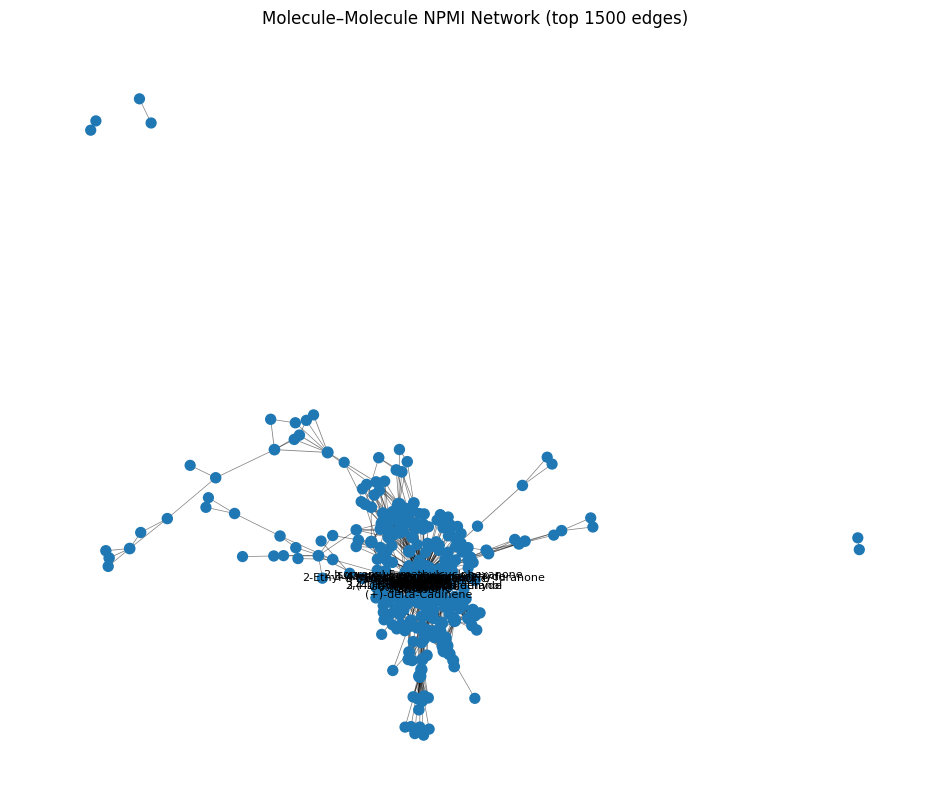

In [21]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# ---- 설정 ----
TOP_DRAW_EDGES = 1500   # 너무 크면 300~800으로 낮추기
LABEL_TOP_NODES = 30    # 라벨 붙일 노드 수 (너무 많으면 지저분)

# ---- 상위 edge로 그래프 구성 ----
draw_df = df.sort_values("npmi", ascending=False).head(TOP_DRAW_EDGES).copy()

G = nx.Graph()
for _, r in draw_df.iterrows():
    a = int(r["molecule_1"])
    b = int(r["molecule_2"])
    w = float(r["npmi"])
    G.add_edge(a, b, weight=w)

print("nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())

# ---- 레이아웃 ----
pos = nx.spring_layout(G, seed=0)  # 느리면 seed 유지, TOP_DRAW_EDGES 줄이기

# ---- 노드 크기: weighted degree(= sum of npmi) 기반 ----
wdeg = dict(G.degree(weight="weight"))
node_sizes = np.array([wdeg[n] for n in G.nodes()])
# 보기 좋게 스케일링
node_sizes = 50 + 400 * (node_sizes - node_sizes.min()) / (node_sizes.max() - node_sizes.min() + 1e-12)

# ---- 엣지 두께: npmi 기반 ----
edge_weights = np.array([G[u][v]["weight"] for u, v in G.edges()])
edge_widths = 0.5 + 3.0 * (edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min() + 1e-12)

plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G, pos, node_size=node_sizes)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.5)

# ---- 라벨: weighted degree 상위 노드만 이름 표시 ----
id2name = {}
# df에 name이 이미 있으니까 빠르게 매핑 구성
for _, r in df[["molecule_1", "name_1"]].dropna().drop_duplicates().iterrows():
    id2name[int(r["molecule_1"])] = str(r["name_1"])
for _, r in df[["molecule_2", "name_2"]].dropna().drop_duplicates().iterrows():
    id2name[int(r["molecule_2"])] = str(r["name_2"])

top_nodes = sorted(G.nodes(), key=lambda n: wdeg.get(n, 0.0), reverse=True)[:LABEL_TOP_NODES]
labels = {n: id2name.get(n, str(n)) for n in top_nodes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

plt.title(f"Molecule–Molecule NPMI Network (top {TOP_DRAW_EDGES} edges)")
plt.axis("off")
plt.show()

Interactive 시각화

In [16]:
# [ONE CELL - FULL SCRIPT v3]
# Fix: make edges clearly visible by setting edge width + alpha color explicitly.

import numpy as np
import pandas as pd
import networkx as nx
from pathlib import Path
from collections import Counter
import re
from pyvis.network import Network
from IPython.display import FileLink, display

# -----------------------------
# Settings
# -----------------------------
TOP_DRAW_EDGES  = 1500
LABEL_TOP_NODES = 50

MIN_NODE_SIZE = 3
SIZE_SCALE    = 7

TOP_FLAVOR_WORDS = 6

# ✅ Edge visibility controls (핵심)
EDGE_ALPHA = 0.8            # 0.15~0.35 추천 (진하게 하려면 ↑)
EDGE_W_MIN = 0.4             # 최소 두께
EDGE_W_MAX = 4.0             # 최대 두께 (너무 굵으면 2.5~3.5)

OUT_HTML = Path("../result/molecule_npmi_network_interactive.html")
OUT_HTML.parent.mkdir(exist_ok=True)

# ✅ softer palette
palette = [
    "#4E79A7", "#F28E2B", "#59A14F", "#E15759",
    "#B07AA1", "#9C755F", "#FF9DA7", "#76B7B2",
    "#EDC948", "#BAB0AC", "#8CD17D", "#B6992D",
    "#86BCB6", "#D4A6C8", "#A0CBE8", "#FFBE7D",
]
def comm_color(cid: int) -> str:
    return palette[int(cid) % len(palette)]

def parse_flavor_tokens(s: str):
    if s is None:
        return []
    s = str(s).strip()
    if not s or s.lower() == "nan":
        return []
    s = s.strip("{}")
    parts = [p.strip().strip("'").strip('"') for p in s.split(",")]
    toks = [re.sub(r"\s+", " ", p.lower()).strip() for p in parts if p and p.strip()]
    return [t for t in toks if t]

# -----------------------------
# Sanity checks
# -----------------------------
need_cols = ["molecule_1", "molecule_2", "npmi"]
for c in need_cols:
    if c not in df.columns:
        raise ValueError(f"df에 필요한 컬럼 '{c}'가 없습니다. columns={list(df.columns)}")

# -----------------------------
# 1) Build graph from top NPMI edges
# -----------------------------
draw_df = df.sort_values("npmi", ascending=False).head(TOP_DRAW_EDGES).copy()

G = nx.Graph()
for _, r in draw_df.iterrows():
    a = int(r["molecule_1"])
    b = int(r["molecule_2"])
    w = float(r["npmi"])
    if a != b:
        G.add_edge(a, b, weight=w)

print("nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())

# -----------------------------
# 2) Molecule id -> name/flavor map
# -----------------------------
id2name, id2fp = {}, {}

cols1 = [c for c in ["name_1", "flavor_profile_1"] if c in df.columns]
cols2 = [c for c in ["name_2", "flavor_profile_2"] if c in df.columns]

if cols1:
    tmp = df[["molecule_1"] + cols1].dropna(subset=["molecule_1"]).drop_duplicates()
    for _, r in tmp.iterrows():
        mid = int(r["molecule_1"])
        if "name_1" in r and pd.notna(r["name_1"]):
            id2name.setdefault(mid, str(r["name_1"]))
        if "flavor_profile_1" in r and pd.notna(r["flavor_profile_1"]):
            id2fp.setdefault(mid, str(r["flavor_profile_1"]))

if cols2:
    tmp = df[["molecule_2"] + cols2].dropna(subset=["molecule_2"]).drop_duplicates()
    for _, r in tmp.iterrows():
        mid = int(r["molecule_2"])
        if "name_2" in r and pd.notna(r["name_2"]):
            id2name.setdefault(mid, str(r["name_2"]))
        if "flavor_profile_2" in r and pd.notna(r["flavor_profile_2"]):
            id2fp.setdefault(mid, str(r["flavor_profile_2"]))

# -----------------------------
# 3) Weighted degree + community detection
# -----------------------------
wdeg = dict(G.degree(weight="weight"))

try:
    from networkx.algorithms.community import greedy_modularity_communities
    comms = list(greedy_modularity_communities(G, weight="weight"))
    node2comm = {}
    for i, cset in enumerate(comms):
        for n in cset:
            node2comm[n] = int(i)
    print("#communities:", len(comms))
except Exception as e:
    print("[WARN] community detection failed:", e)
    node2comm = {n: 0 for n in G.nodes()}

# -----------------------------
# 4) Community legend: representative flavor words (weighted by wdeg)
# -----------------------------
comm2nodes = {}
for n in G.nodes():
    cid = int(node2comm.get(n, 0))
    comm2nodes.setdefault(cid, []).append(n)

legend_rows = []
for cid, nodes in sorted(comm2nodes.items()):
    token_w = Counter()
    for n in nodes:
        deg = float(wdeg.get(n, 0.0))
        for t in parse_flavor_tokens(id2fp.get(n, "")):
            token_w[t] += deg
    rep_flavors = ", ".join([w for w, _ in token_w.most_common(TOP_FLAVOR_WORDS)])
    legend_rows.append({
        "community_id": str(cid),
        "color_hex": comm_color(cid),
        "representative_flavors": rep_flavors
    })
legend_df = pd.DataFrame(legend_rows)

# -----------------------------
# 5) Build PyVis network
# -----------------------------
net = Network(
    height="850px",
    width="100%",
    bgcolor="#ffffff",
    font_color="black",
    notebook=False,
    cdn_resources="in_line"
)

top_nodes = sorted(G.nodes(), key=lambda n: wdeg.get(n, 0.0), reverse=True)[:LABEL_TOP_NODES]
top_set = set(top_nodes)

deg_vals = np.array([wdeg.get(n, 0.0) for n in G.nodes()], dtype=float)
deg_vals = np.maximum(deg_vals, 1e-12)
deg_scaled = MIN_NODE_SIZE + SIZE_SCALE * np.log1p(deg_vals)

for n, size in zip(G.nodes(), deg_scaled):
    name = id2name.get(n, str(n))
    fp   = id2fp.get(n, "")
    deg  = wdeg.get(n, 0.0)
    cid  = int(node2comm.get(n, 0))
    hx   = comm_color(cid)

    title = (
        f"<b>{name}</b><br>"
        f"Molecule ID: {n}<br>"
        f"Community: {cid}<br>"
        f"Weighted degree (sum NPMI): {deg:.3f}<br>"
        f"Flavor profile: {fp}"
    )

    fixed_color = {
        "background": hx,
        "border": "rgba(0,0,0,0)",
        "highlight": {"background": hx, "border": "rgba(0,0,0,0)"},
        "hover":     {"background": hx, "border": "rgba(0,0,0,0)"},
    }

    net.add_node(
        n,
        label=name if n in top_set else "",
        title=title,
        size=float(size),
        group=str(cid),
        color=fixed_color,
        borderWidth=0,
        borderWidthSelected=0
    )

# -----------------------------
# ✅ Edge scaling: explicitly set width + alpha color
# -----------------------------
# get weights from current graph (top edges)
edge_ws = np.array([float(d["weight"]) for _, _, d in G.edges(data=True)], dtype=float)
if len(edge_ws) > 0:
    # NPMI can be [-1,1], but we're taking top edges so usually positive.
    # Still: make it robust.
    wmin = float(np.min(edge_ws))
    wmax = float(np.max(edge_ws))
else:
    wmin = 0.0
    wmax = 1.0

def scale_edge_width(w):
    # robust scaling (avoid divide-by-zero)
    if wmax - wmin < 1e-12:
        return (EDGE_W_MIN + EDGE_W_MAX) / 2.0
    t = (w - wmin) / (wmax - wmin)
    return EDGE_W_MIN + (EDGE_W_MAX - EDGE_W_MIN) * float(t)

EDGE_COLOR = f"rgba(120,120,120,{EDGE_ALPHA})"

for u, v, d in G.edges(data=True):
    w = float(d["weight"])
    net.add_edge(
        u, v,
        width=scale_edge_width(w),   # ✅ thickness you can see
        color=EDGE_COLOR,            # ✅ visible gray with alpha
        title=f"NPMI: {w:.3f}",
        smooth=False
    )

net.set_options("""
var options = {
  "nodes": { "chosen": false },
  "edges": { "chosen": false },
  "interaction": {
    "hover": true,
    "navigationButtons": true,
    "keyboard": true,
    "selectable": false
  },
  "physics": {
    "forceAtlas2Based": {
      "gravitationalConstant": -70,
      "centralGravity": 0.01,
      "springLength": 140,
      "springConstant": 0.06
    },
    "maxVelocity": 30,
    "solver": "forceAtlas2Based",
    "timestep": 0.12,
    "stabilization": {"enabled": true, "iterations": 250}
  }
}
""")

net.save_graph(str(OUT_HTML))
print(f"[DONE] Saved base HTML → {OUT_HTML}")

# -----------------------------
# 6) Inject legend + dim script (nodes only; edges stay visible)
# -----------------------------
items_html = []
for _, r in legend_df.sort_values("community_id").iterrows():
    cid = str(r["community_id"])
    hx  = str(r["color_hex"])
    flavors = str(r["representative_flavors"])
    items_html.append(f"""
      <div class="legend-item" data-cid="{cid}" data-color="{hx}"
           style="display:flex; gap:10px; align-items:flex-start; margin:6px 0; cursor:pointer;">
        <div class="swatch" style="width:14px; height:14px; background:{hx}; border:0; margin-top:3px; border-radius:3px;"></div>
        <div style="line-height:1.25;">
          <div><b>Community {cid}</b></div>
          <div style="font-size:12px; opacity:0.9;">{flavors}</div>
        </div>
      </div>
    """)

legend_box = f"""
<!-- === injected legend dim FINAL === -->
<div id="flavorLegend" style="
  position: fixed;
  right: 12px;
  top: 12px;
  width: 390px;
  max-height: 86vh;
  overflow: auto;
  background: rgba(255,255,255,0.95);
  border: 1px solid #ddd;
  box-shadow: 0 4px 18px rgba(0,0,0,0.12);
  border-radius: 12px;
  padding: 12px 12px;
  font-family: Arial, sans-serif;
  z-index: 9999;
">
  <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:8px;">
    <div style="font-weight:700;">Legend (click to dim others)</div>
    <div style="display:flex; gap:8px;">
      <button id="resetDimBtn"
              style="border:0; background:#eee; padding:4px 8px; border-radius:8px; cursor:pointer;">
        Reset
      </button>
      <button onclick="document.getElementById('flavorLegend').style.display='none';"
              style="border:0; background:#eee; padding:4px 8px; border-radius:8px; cursor:pointer;">
        ✕
      </button>
    </div>
  </div>
  <div style="font-size:12px; opacity:0.8; margin-bottom:10px;">
    Click a community: selected stays <b>exactly</b> legend color; others dim.
  </div>
  {''.join(items_html)}
</div>
"""

legend_js = r"""
<script>
(function(){
  function whenReady(cb){
    let tries = 0;
    const t = setInterval(() => {
      tries++;
      if (typeof window.nodes !== "undefined" && typeof window.network !== "undefined") {
        clearInterval(t);
        cb(window.nodes, window.network);
      }
      if (tries > 200) { clearInterval(t); console.warn("[LegendDimFinal] timed out"); }
    }, 50);
  }

  function cssToRgba(css, alpha){
    const ctx = document.createElement("canvas").getContext("2d");
    ctx.fillStyle = css;
    const v = ctx.fillStyle;
    if (v.startsWith("#")) {
      const r = parseInt(v.slice(1,3),16), g = parseInt(v.slice(3,5),16), b = parseInt(v.slice(5,7),16);
      return `rgba(${r},${g},${b},${alpha})`;
    }
    if (v.startsWith("rgb(")) return v.replace("rgb(", "rgba(").replace(")", `,${alpha})`);
    if (v.startsWith("rgba(")) {
      return v.replace(/rgba\(([^)]+)\)/, (m, inside) => {
        const p = inside.split(",").map(s => s.trim());
        return `rgba(${p[0]},${p[1]},${p[2]},${alpha})`;
      });
    }
    return `rgba(150,150,150,${alpha})`;
  }

  function vividColor(hex){
    return {
      background: hex,
      border: "rgba(0,0,0,0)",
      highlight: { background: hex, border: "rgba(0,0,0,0)" },
      hover:     { background: hex, border: "rgba(0,0,0,0)" }
    };
  }

  function dimColor(hex){
    return {
      background: cssToRgba(hex, 0.10),
      border: "rgba(0,0,0,0)",
      highlight: { background: cssToRgba(hex, 0.14), border: "rgba(0,0,0,0)" },
      hover:     { background: cssToRgba(hex, 0.14), border: "rgba(0,0,0,0)" }
    };
  }

  whenReady((nodes, network) => {
    try {
      network.setOptions({
        nodes: { chosen: false },
        edges: { chosen: false },
        interaction: { selectable: false }
      });
    } catch(e) {}

    const comm2hex = {};
    document.querySelectorAll(".legend-item").forEach(el => {
      const cid = String(el.getAttribute("data-cid"));
      const hx  = String(el.getAttribute("data-color"));
      comm2hex[cid] = hx;
    });

    const meta = new Map();
    nodes.get().forEach(n => meta.set(n.id, { group: String(n.group), font: n.font }));

    let activeCid = null;

    function paint(selectedCid){
      selectedCid = selectedCid === null ? null : String(selectedCid);
      try { network.unselectAll(); } catch(e) {}

      const all = nodes.get();
      const updates = all.map(n => {
        const m = meta.get(n.id) || { group: String(n.group), font: n.font };
        const g = String(m.group);
        const hx = comm2hex[g] || "#999999";

        if (selectedCid === null) {
          return { id: n.id, color: vividColor(hx), font: m.font, borderWidth: 0, borderWidthSelected: 0 };
        }
        if (g === selectedCid) {
          return { id: n.id, color: vividColor(hx), font: m.font, borderWidth: 0, borderWidthSelected: 0 };
        }
        return { id: n.id, color: dimColor(hx), font: { color: "rgba(60,60,60,0.20)" }, borderWidth: 0, borderWidthSelected: 0 };
      });

      nodes.update(updates);
      try { network.unselectAll(); } catch(e) {}
    }

    function applyDim(cid){ activeCid = String(cid); paint(activeCid); }
    function resetDim(){ activeCid = null; paint(null); }

    paint(null);

    document.querySelectorAll(".legend-item").forEach(el => {
      el.addEventListener("click", () => {
        const cid = String(el.getAttribute("data-cid"));
        if (activeCid !== null && String(activeCid) === cid) resetDim();
        else applyDim(cid);
      });
    });

    const btn = document.getElementById("resetDimBtn");
    if (btn) btn.addEventListener("click", resetDim);
  });
})();
</script>
"""

html = OUT_HTML.read_text(encoding="utf-8", errors="ignore")

# remove previous injections
for pat in [
    r"<!-- === injected legend dim FINAL === -->.*?(?=</body>)",
    r"<script>\s*\(function\(\)\{.*?\}\)\(\);\s*</script>",  # overly broad, but ok if you only inject one custom script
]:
    html = re.sub(pat, "", html, flags=re.DOTALL)

if "</body>" in html:
    html = html.replace("</body>", legend_box + "\n" + legend_js + "\n</body>")
else:
    html = html + "\n" + legend_box + "\n" + legend_js

OUT_HTML.write_text(html, encoding="utf-8")
print(f"[DONE] Final HTML saved → {OUT_HTML}")

display(FileLink(str(OUT_HTML)))


nodes: 304 edges: 1500
#communities: 11
[DONE] Saved base HTML → ../result/molecule_npmi_network_interactive.html
[DONE] Final HTML saved → ../result/molecule_npmi_network_interactive.html


/home/samyang/FlavorDB2/result/molecule_npmi_network_interactive.html

### 2-3. “중요 molecule” 랭킹 시각화 (weighted degree Top-K)

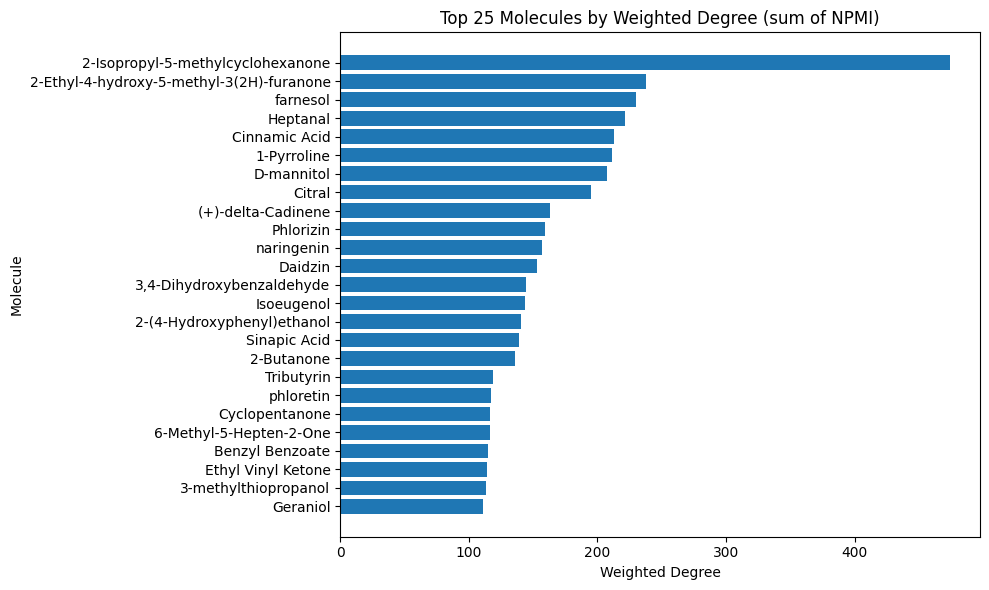

,molecule,molecule_name,weighted_degree
0,6986,2-Isopropyl-5-methylcyclohexanone,473.901357
1,33931,2-Ethyl-4-hydroxy-5-methyl-3(2H)-furanone,237.821677
2,445070,farnesol,230.143324
3,8130,Heptanal,221.389009
4,444539,Cinnamic Acid,212.589345
5,79803,1-Pyrroline,211.656594
6,6251,D-mannitol,207.597655
7,638011,Citral,194.712982
8,441005,(+)-delta-Cadinene,163.208478
9,6072,Phlorizin,159.403058


In [34]:
import pandas as pd
import matplotlib.pyplot as plt

TOPK_NODES = 25

# weighted degree 계산
wdeg_series = pd.Series(wdeg).sort_values(ascending=False).head(TOPK_NODES)

labels = [id2name.get(int(mid), str(mid)) for mid in wdeg_series.index]
values = wdeg_series.values

plt.figure(figsize=(10, 6))
plt.barh(labels[::-1], values[::-1])
plt.title(f"Top {TOPK_NODES} Molecules by Weighted Degree (sum of NPMI)")
plt.xlabel("Weighted Degree")
plt.ylabel("Molecule")
plt.tight_layout()
plt.show()

# 테이블도 같이
rank_df = pd.DataFrame({
    "molecule": wdeg_series.index.astype(int),
    "molecule_name": [id2name.get(int(mid), "(unknown)") for mid in wdeg_series.index],
    "weighted_degree": wdeg_series.values
})
display(rank_df)
